# Dataset

Use the UCI Bike Sharing dataset:

- Dataset page: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
- Citation: Fanaee-T (2013), UCI Machine Learning Repository
- DOI: https://doi.org/10.24432/C5W894
- License: CC BY 4.0

In [37]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

df = fetch_ucirepo(id=275)
bike_sharing = df.data.original.copy()
bike_sharing

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [38]:
X = df.data.features.copy()
X.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


The target is `cnt`, the total rental count.

Please note that `cnt = casual + registered`, which are forbidden predictors and removed before any model is trained.
> They are grouped as "Other" on the ucimlrepo and therefore does not show up on our features table.

In [39]:
y = df.data.targets.copy()
y.head()

,cnt
0,16
1,40
2,32
3,13
4,1


# Prediction-time contract

For the main experiment, assume a prediction is made immediately before an hour begins. Calendar information and a weather forecast are considered available. Actual rental counts during that hour are not available.

Write down the limitations of treating recorded weather observations as if they were forecasts. This is an educational approximation, not proof that the same performance would occur in a live forecasting system.

# Learning objectives

By the end, you should be able to:

- frame and evaluate a regression problem;
- identify exact target leakage from feature definitions;
- parse and derive useful information from a date column;
- build a naive regression baseline;
- compare random and chronological splits;
- interpret MAE, RMSE, R-squared, and residuals;
- distinguish interpolation from forecasting into a later period;
- explain why an impressive random-split score can be misleading.

# Rules and scope

You must:

- record a fixed random seed;
- use `hour.csv` (or use the `ucimlrepo` api) and predict `cnt`;
- remove casual, registered, and the row identifier instant;
- verify the arithmetic leakage relationship before removing its columns;
- build a naive baseline and a linear regression model;
- run both a random-split experiment and a chronological-split experiment;
- perform preprocessing inside a scikit-learn pipeline;
- report MAE, RMSE, and R-squared;
- inspect residuals and time-related error patterns;
- maintain an experiment log and final reflection.

You may:

- use pandas, NumPy, Matplotlib, Seaborn, and scikit-learn;
- derive calendar features from dteday;
- add one optional nonlinear model after the required experiments;
- transform the target only as an optional extension with careful interpretation.

Do not:

- copy an existing Bike Sharing solution notebook;
- use casual or registered as predictors;
- shuffle data for the chronological experiment;
- use future target values as lag features in this introductory project;
- use neural networks or broad hyperparameter searches;
- use MLflow, Docker, deployment, or cloud infrastructure;
- repeatedly tune against the final chronological test period.

# Notebook structure and exact checkpoints

Use the numbered headings below in your notebook.

## 0. Project header and reproducibility

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

Include:

- project title, your name, and date;
- fixed seed;
- prediction-time contract;
- imports;
- dataset citation and URL.

Checkpoint:

- What does one row represent?
- What quantity is being predicted, and in what units?
- At what moment is the prediction assumed to be made?

## 1. Load and establish data shape

Load `hour.csv` and inspect:

- ✅ object type and shape;
- ✅ column names and first rows;
- ✅ dtypes `(df.shape)`;
- ✅ target summary `(df.describe)`;
- ✅ dataset date range `(X.dteday.value_counts())`;
- ✅ whether timestamps are already in chronological order (looks like yes by looking at `X.dteday.is_monotonic_increasing`).

---

Required assertions after parsing the date:

```python
assert "cnt" in df.columns
assert df["dteday"].notna().all()
assert df["cnt"].ge(0).all()
```

In [41]:
print(X.shape)
print(y.shape)

(17379, 13)
(17379, 1)


In [42]:
y.describe()

,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


In [43]:
X.dteday.value_counts()

,count
dteday,
2012-12-31,24
2011-01-01,24
2012-12-30,24
2012-12-29,24
2012-12-28,24
...,...
2011-01-26,16
2011-01-18,12
2012-10-30,11


In [44]:
X.dteday.is_monotonic_increasing

True

In [45]:
assert "cnt" in y.columns
assert X["dteday"].notna().all()
assert y["cnt"].ge(0).all()

In [46]:
X.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


Checkpoint:

- How many hourly observations are present?
> A maximum of 24 observations (per hour per day) is present, although some dates (like `2012-10-29`) have fewer than 24 observations. There is a total of `17379` observations between `2011-01-01` to `2012-12-31`.

- Does every calendar day contain exactly 24 rows? If not, do not silently manufacture rows; describe what you observe.
> No, not everyday has 24 observations.

- Which columns are coded as integers even though they represent categories?
> `season`, `yr`, `mnth`, `hr`, `weekday` and `weathersit` (shown on Variables Table on https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset). Also, `holiday` and `workingday` are integers but are binary indicators.

## 2. Data audit and visualization

Audit:

- ✅ missing values (`X.isnull().sum()`, no missing values!);
- ✅ duplicate rows (`X.duplicated().sum()`, no duplicated rows);
- ✅ unique values for coded categorical columns (`X.nunique()`);
- ✅ numerical summaries and suspicious values (`X.describe()`);
- ✅ target distribution and skew (`y.plot.hist()`);
- ✅ demand across hour, weekday, month, and weather situation (`bike_sharing.groupby('hr').cnt.mean().plot.bar()` - substitute `hr` to `weekday`, `mnth` or `weathersit`);
- ✅ the relationship among `cnt`, `casual`, and `registered`(`(bike_sharing['casual'] + bike_sharing['registered'] == bike_sharing['cnt']).all()`).

Required visualizations:

- ✅ distribution of hourly `cnt` (see demand above);
- ✅ average or median demand by hour of day (`bike_sharing.groupby('hr').cnt.agg(["mean", "median"]).plot()`);
- ✅ demand over a sensible chronological slice (`bike_sharing.groupby('dteday').cnt.mean().iloc[11:17].plot()`);
- ✅ demand grouped by one weather or calendar category (see demand above).

Required leakage check: calculate whether `cnt == casual + registered` for every row and report the result.

In [47]:
X.isnull().sum()

,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [48]:
X.duplicated().sum()

np.int64(0)

In [49]:
X.nunique()

,0
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4
temp,50


In [50]:
X.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700


<Axes: ylabel='Frequency'>

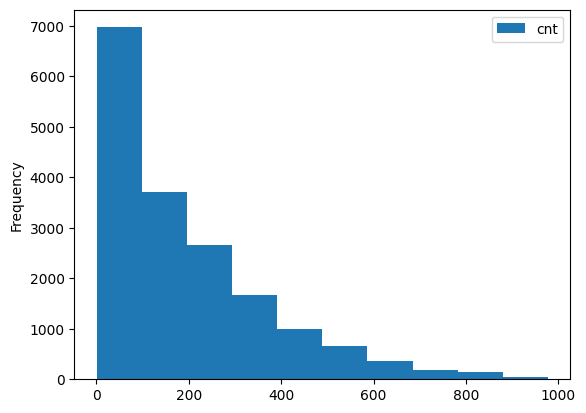

In [51]:
y.plot.hist()

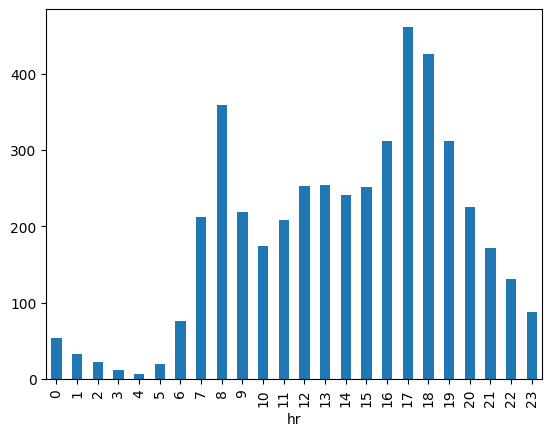

In [52]:
bike_sharing.groupby('hr').cnt.mean().plot.bar().ticklabel_format(style='plain', axis='y')

In [53]:
(bike_sharing['casual'] + bike_sharing['registered'] == bike_sharing['cnt']).all()

np.True_

<Axes: xlabel='hr'>

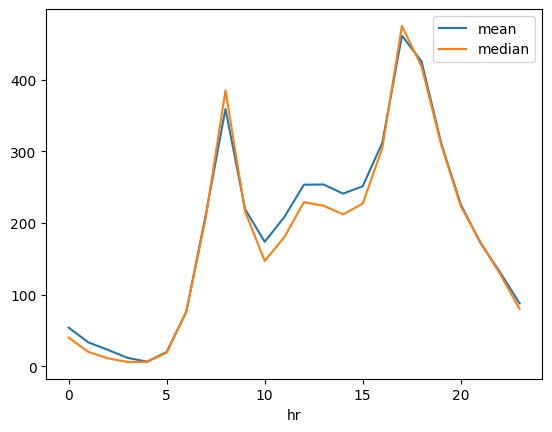

In [54]:
bike_sharing.groupby('hr').cnt.agg(["mean", "median"]).plot()

<Axes: xlabel='dteday'>

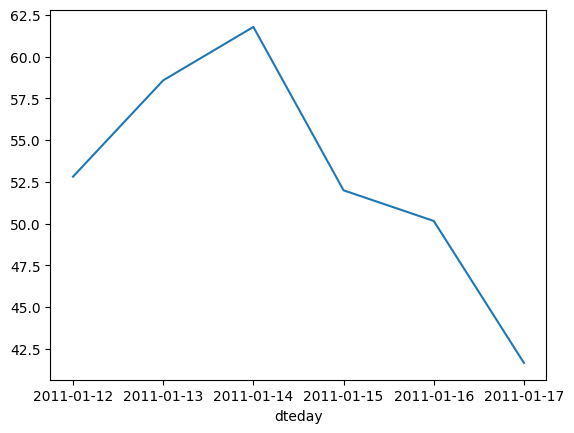

In [55]:
bike_sharing.groupby('dteday').cnt.mean().iloc[11:17].plot()

Checkpoint:

- Is the target symmetric or skewed?
> Target is heavily skewed towards `<100` rentals per day.

- Are integer category codes quantities with meaningful numerical distance?
>  Not generally. For example, weather category 3 does not mean three times as much weather as category 1. Calendar features such as hour and month also wrap around: hours 23 and 0 are adjacent despite their numerical difference.

- Why would using casual and registered make the task meaningless?
> Because `casual + registered = cnt`, so they directly reveal the answer. They are also unavailable before the hour begins, when the prediction must be made.

- Which patterns suggest that time affects demand?
> The demand by hour chart shows that rentals are heavily concentrated in morning (8AM) and afternoon (6PM).

## 3. Define features and roles

Remove (already done as `X` and `y`):

- `cnt` from the feature table because it is the target;
- `casual` and registered because they reveal the target;
- `instant` because it is a row identifier.

Parse `dteday`. Either derive documented calendar features and then remove the raw date, or explain another pipeline-safe representation. Do not pass raw date strings directly to a standard estimator.

Create explicit lists of:

- numerical continuous features;
- categorical or binary features;
- derived date features, if any;
- forbidden or removed columns.

Required checks:

```python
for forbidden in ["cnt", "casual", "registered", "instant"]:
    assert forbidden not in X.columns

assert set(numeric_features).isdisjoint(categorical_features)
assert set(numeric_features) | set(categorical_features) == set(X.columns)
```

The final equality assumes the raw date has already been removed or converted.

In [56]:
# Split X into numerical / categorical and date features
numeric_features = X[['temp', 'atemp', 'hum', 'windspeed']] # Continuous features
categorical_features = X[['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']]
date_features = pd.to_datetime(X['dteday'])

# Assert that the 3 separate features combined together equals to X and that dteday is under datetime format
for forbidden in ["cnt", "casual", "registered", "instant"]:
    assert forbidden not in X.columns

assert set(numeric_features).isdisjoint(categorical_features)
assert set(numeric_features) | set(categorical_features) | {date_features.name} == set(X.columns) # Must use dict brackets for date_features since its a series (only has dteday)
assert pd.api.types.is_datetime64_any_dtype(date_features)

Checkpoint:

- Why is `hr` categorical or cyclical rather than an ordinary continuous quantity?
> Because there is no continous relationship between `hr` of say `0` and `23`, as it represents different hours during the day, not a procession of continuous numbers like say `temp`.

- Why might treating month `12` as far from month `1` be undesirable?
> December and January are consecutive months, even though their codes differ by 11. Treating month as an ordinary number does not represent this yearly.

- What information does `yr` encode, and could a model misuse it as a shortcut?
> `yr` indicates 2011 (`0`) or 2012 (`1`). A model could use it to capture differences in overall demand between those years rather than learning patterns that remain useful in future years. That relationship may not generalize beyond the two observed years.

## 4. Create two evaluation designs

Build and clearly name two splits.

**Experiment A: random split**
- Use an 80/20 split with the fixed seed.
- This is a conventional tabular comparison, not the final forecasting claim.

**Experiment B: chronological split**
- Sort by date and hour first.
- Use the earliest 80% for training and latest 20% for testing.
- Do not shuffle.
- Report the boundary timestamp and date ranges on both sides.

For both experiments, display all train/test shapes and confirm index non-overlap.

In [57]:
# Experiment A: random split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Experiment B: chronological split
X_sorted = X.sort_values(['dteday', 'hr'])
y_sorted = y.loc[X_sorted.index]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_sorted, y_sorted, test_size=0.2, shuffle=False)

# Display all shapes
assert X_train_a.shape == X_train_b.shape
assert X_test_a.shape == X_test_b.shape
assert y_train_a.shape == y_train_b.shape
assert y_test_a.shape == y_test_b.shape

print(X_train_a.shape)
print(X_test_a.shape)
print(y_train_a.shape)
print(y_test_a.shape)

# No overlapping row indices
assert set(X_train_a.index).isdisjoint(X_test_a.index)
assert set(y_train_a.index).isdisjoint(y_test_a.index)
assert set(X_train_b.index).isdisjoint(X_test_b.index)
assert set(y_train_b.index).isdisjoint(y_test_b.index)

(13903, 13)
(3476, 13)
(13903, 1)
(3476, 1)


Checkpoint:

- In the random split, can later observations help train a model evaluated on earlier observations?
> Yes. Random splitting can put later observations in training and earlier observations in testing.

- Which split better resembles predicting future demand?
> Experiment b because all training observations occur before the test observations.

- Why might the chronological experiment be harder?
> Later demand patterns may differ from those in the training period. The model must generalize to a future period without training examples from that period.

- Is a single chronological holdout enough for a production forecasting claim?
> No. It measures performance on only one later period. We would need evaluations across several time periods to check whether performance is consistent across seasons and changing demand.

## 5. Establish naive baselines

Use a `DummyRegressor` with a constant strategy such as the training-target mean. Fit a separate baseline for each split.

Report:

- MAE (`mean_aboslute_error`);
- RMSE (`root_mean_square_error`);
- R-squared (`r2_score`);
- the training-target constant used for prediction (`strategy="mean"`).

In [58]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import(
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

# Create and train the baseline for Experiment A
dummy_model_a = DummyRegressor(strategy="mean")
dummy_model_a.fit(X_train_a, y_train_a)
y_pred_dummy_a = dummy_model_a.predict(X_test_a)

# Create and train the baseline for Experiment B
dummy_model_b = DummyRegressor(strategy="mean")
dummy_model_b.fit(X_train_b, y_train_b)
y_pred_dummy_b = dummy_model_b.predict(X_test_b)

# Evaluate MAE, RMSE and R-squared for Experiment A and Experiment B
MAE_a = mean_absolute_error(y_test_a, y_pred_dummy_a)
RMSE_a = root_mean_squared_error(y_test_a, y_pred_dummy_a)
R_squared_a = r2_score(y_test_a, y_pred_dummy_a)

MAE_b = mean_absolute_error(y_test_b, y_pred_dummy_b)
RMSE_b = root_mean_squared_error(y_test_b, y_pred_dummy_b)
R_squared_b = r2_score(y_test_b, y_pred_dummy_b)

# Displays
baseline_results = pd.DataFrame({
    "Experiment": ["A: Random", "B: Chronological"],
    "Training-target mean": [dummy_model_a.constant_.item(), dummy_model_b.constant_.item(),],
    "MAE": [MAE_a, MAE_b],
    "RMSE": [RMSE_a, RMSE_b],
    "R-squared": [R_squared_a, R_squared_b],
})
baseline_results

,Experiment,Training-target mean,MAE,RMSE,R-squared
0,A: Random,189.263324,143.120391,182.674857,-0.000030
1,B: Chronological,174.639143,174.984601,232.608375,-0.112995


Checkpoint:

- What does the MAE mean in approximate bikes per hour?
> An MAE of 100 means predictions are off by 100 rentals per hour on average, ignoring whether they are too high or too low.

- Why is RMSE usually larger than MAE?
> **RMSE squares errors, averages them, then takes the square root**. This gives large errors more influence than MAE does.

- What does an R-squared value near zero mean relative to this baseline?
> The model performs about as well as always predicting the test set’s average rental count, when measured by squared error.

- Can R-squared be negative on test data? Explain conceptually.
> Negative test R-squared means the model has greater total squared error than a constant prediction equal to the test-target mean (e.g. the validation mean might be noticeably different than that of training, causing the model to underperform in validation).

## 6. Build the linear-model pipeline

Build a scikit-learn pipeline that:

- processes numeric and categorical columns appropriately;
- fits learned preprocessing only on training rows;
- one-hot encodes category codes rather than assuming all codes are continuous;
- trains a regularized linear regression model such as `Ridge`.

Use the same feature logic and major model settings in both split experiments so the evaluation design is the main difference.

In [59]:
# Skip missing-value imputation because the audit found no missing values

# Define numerical scaling and categorical one-hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    # For numeric_features, select numeric columns by name, then scale using training means and standard deviations
    # For categorical_features, select categorical columns by name, then create one indicator per learned category with unseen categories at prediction time get all-zero indicators for that feature
    # .columns.tolist() provides the names of columns to transform with the respective preprocessing
    ("numeric", StandardScaler(), numeric_features.columns.tolist()),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features.columns.tolist()),
], remainder="drop") # Drop the remainder columns (date_features, since calendar information like yr, mnth, weekday and hr are already available in categorical_features)

# Trains a regularized linear regression model such as Ridge
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.base import clone

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0)),
])

model_a = clone(ridge_pipeline)
model_b = clone(ridge_pipeline)

model_a.fit(X_train_a, y_train_a)
model_b.fit(X_train_b, y_train_b)

y_pred_a = model_a.predict(X_test_a)
y_pred_b = model_b.predict(X_test_b)

Checkpoint:

- Which preprocessing steps learn state?
> `StandardScaler` learns each numerical column’s training mean and standard deviation. `OneHotEncoder` learns which categories appear in the training data.

- Why can one-hot encoding be more appropriate for season or weathersit?
> Because we want to insure that the integers in these categorical columns are treated as indicators rather than continous numbers.

- Why is regularization useful after one-hot encoding?
> One-hot encoding creates multiple indicator columns, some of which may be rare or correlated. **Ridge regularization discourages excessively large coefficients, helping reduce overfitting and stabilize predictions**.

- What behavior can a linear model not express easily for hour-of-day demand?
> With one-hot-encoded hours, the model can learn separate morning and evening peaks. However, without interaction features, it cannot easily learn that the hourly demand pattern differs between working days and non-working days. For example, the pipeline gives **8 AM one coefficient** and **working day another**. It doesn’t give **“8 AM specifically on a working day”** its own coefficient.

## 7. Evaluate both valid models

For the random and chronological models, report:

- MAE;
- RMSE;
- R-squared;
- mean residual;
- median absolute error.

Use a consistent sign convention such as:

```text
residual = actual - predicted
```

State your convention in the notebook.

Required plots for each split:

1. predicted versus actual values with a reference diagonal;
2. residual distribution;
3. residuals versus predictions.

For the chronological experiment, also plot actual and predicted demand over a contiguous portion of the test period.

In [60]:
from sklearn.metrics import(
    # mean_absolute_error, ALREADY IMPORTED
    # root_mean_squared_error, ALREADY IMPORTED
    # r2_score, ALREADY IMPORTED
    median_absolute_error,
)

# Calculate metrics
MAE_a = mean_absolute_error(y_test_a, y_pred_a)
RMSE_a = root_mean_squared_error(y_test_a, y_pred_a)
R_squared_a = r2_score(y_test_a, y_pred_a)
residuals_a = np.asarray(y_test_a).ravel() - np.asarray(y_pred_a).ravel()
mean_residual_a = residuals_a.mean()
median_absolute_error_a = median_absolute_error(y_test_a, y_pred_a)

MAE_b = mean_absolute_error(y_test_b, y_pred_b)
RMSE_b = root_mean_squared_error(y_test_b, y_pred_b)
R_squared_b = r2_score(y_test_b, y_pred_b)
residuals_b = np.asarray(y_test_b).ravel() - np.asarray(y_pred_b).ravel()
mean_residual_b = residuals_b.mean()
median_absolute_error_b = median_absolute_error(y_test_b, y_pred_b)

# Display
ridge_results = pd.DataFrame({
    "Experiment": ["A: Random", "B: Chronological"],
    "MAE": [MAE_a, MAE_b],
    "RMSE": [RMSE_a, RMSE_b],
    "R-squared": [R_squared_a, R_squared_b],
    "mean_residual": [mean_residual_a, mean_residual_b],
    "median_absolute_error": [median_absolute_error_a, median_absolute_error_b],
})
ridge_results

,Experiment,MAE,RMSE,R-squared,mean_residual,median_absolute_error
0,A: Random,76.076467,102.334533,0.686166,1.221077,58.346816
1,B: Chronological,98.868171,133.906687,0.631152,3.974128,71.284684


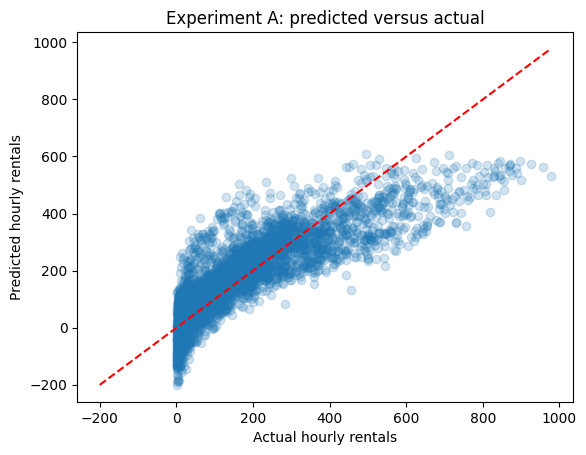

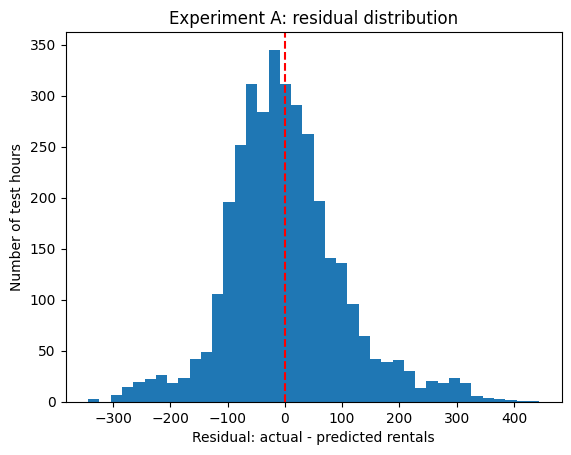

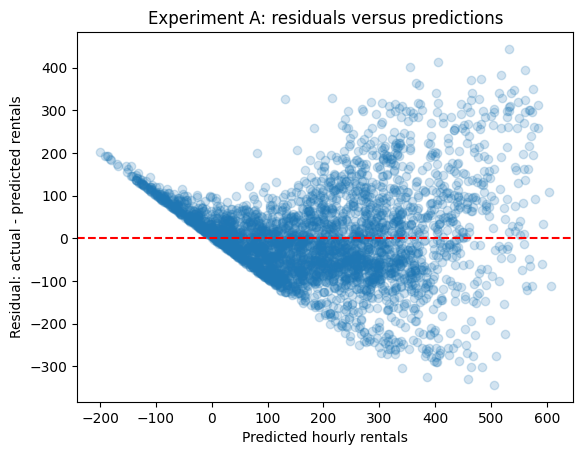

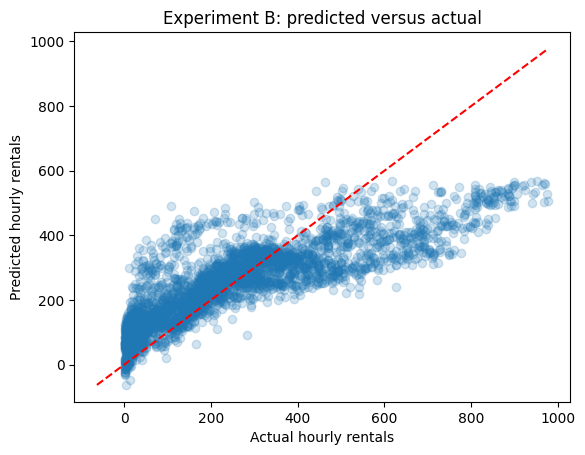

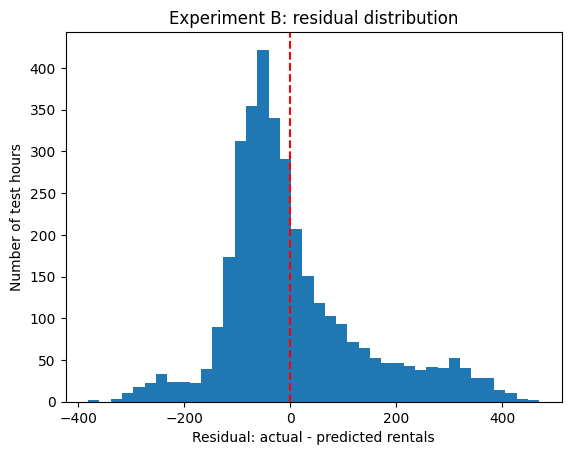

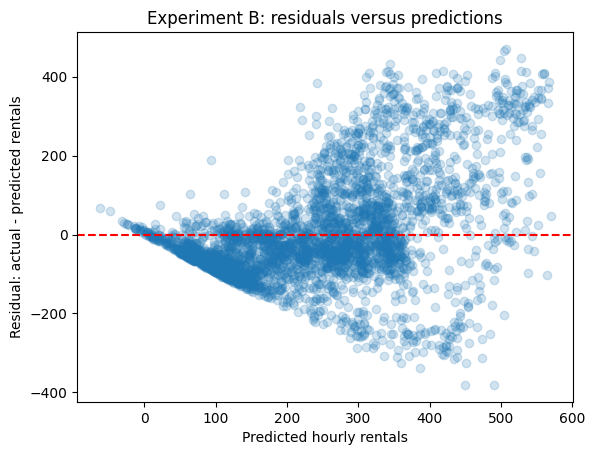

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# ravel() to reshape the y_test to align with y_pred (array)
actual_a = np.asarray(y_test_a).ravel()
predicted_a = np.asarray(y_pred_a).ravel()

actual_b = np.asarray(y_test_b).ravel()
predicted_b = np.asarray(y_pred_b).ravel()

# Experiment A plots

# 1. predicted versus actual values with a reference diagonal;
plt.scatter(actual_a, predicted_a, alpha=0.2)
low = min(actual_a.min(), predicted_a.min())
high = max(actual_a.max(), predicted_a.max())
plt.plot([low, high], [low, high], color="red", linestyle="--")

plt.xlabel("Actual hourly rentals")
plt.ylabel("Predicted hourly rentals")
plt.title("Experiment A: predicted versus actual")
plt.show()

# 2. residual distribution;
plt.hist(residuals_a, bins=40)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual: actual - predicted rentals")
plt.ylabel("Number of test hours")
plt.title("Experiment A: residual distribution")
plt.show()

# 3. residuals versus predictions. (the farther a dot is vertically from the horizontal zero line, the larger its prediction error**)
plt.scatter(predicted_a, residuals_a, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted hourly rentals")
plt.ylabel("Residual: actual - predicted rentals")
plt.title("Experiment A: residuals versus predictions")
plt.show()

# Experiment B plots

# 1. predicted versus actual values with a reference diagonal;
plt.scatter(actual_b, predicted_b, alpha=0.2)
low = min(actual_b.min(), predicted_b.min())
high = max(actual_b.max(), predicted_b.max())
plt.plot([low, high], [low, high], color="red", linestyle="--")

plt.xlabel("Actual hourly rentals")
plt.ylabel("Predicted hourly rentals")
plt.title("Experiment B: predicted versus actual")
plt.show()

# 2. residual distribution;
plt.hist(residuals_b, bins=40)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual: actual - predicted rentals")
plt.ylabel("Number of test hours")
plt.title("Experiment B: residual distribution")
plt.show()

# 3. residuals versus predictions. (the farther a dot is vertically from the horizontal zero line, the larger its prediction error**)
plt.scatter(predicted_b, residuals_b, alpha=0.2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted hourly rentals")
plt.ylabel("Residual: actual - predicted rentals")
plt.title("Experiment B: residuals versus predictions")
plt.show()

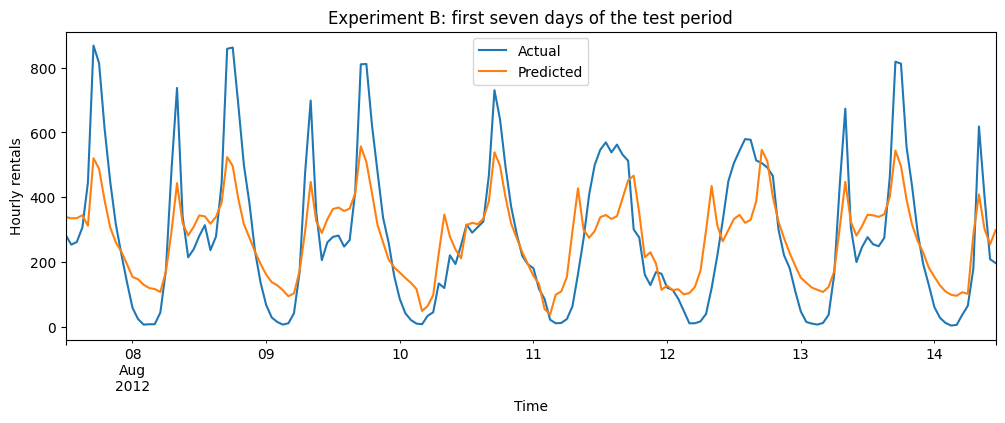

In [62]:
# Plot actual and predicted demand

# Create a DataFrame for comparison that includes X_test_b's date and hour, timestamp, as well as the actual and predicted rentals
comparison = X_test_b[['dteday', 'hr']].copy()
comparison['timestamp'] = (
    pd.to_datetime(comparison['dteday']) + pd.to_timedelta(comparison['hr'], unit='h')
)
comparison['Actual'] = actual_b
comparison['Predicted'] = predicted_b

# Set comparison DataFrame index to 'timestamp' and sort chronologically. Select rows from the earliest test timestamp ('start') up to (not including) 7 days later
comparison = comparison.set_index('timestamp').sort_index()
start = comparison.index.min()
week = comparison.loc[comparison.index < start + pd.Timedelta(days=7)]

# Plot week[['Actual', 'Predicted']]
week[['Actual', 'Predicted']].plot(
    figsize=(12, 4),
    ylabel='Hourly rentals',
    xlabel='Time',
    title='Experiment B: first seven days of the test period',
)
plt.show()

Checkpoint:

- Which split produces better metrics?
> Experiment A (random) is better as all the error / residual stats (MAE, RMSE, median absolute error) are lower and R-square is higher.

- Does the random split overstate likely future performance?
> Random-split MAE is about 76 rentals per hour, compared with 99 for the chronological split. The random evaluation makes performance look better than when predicting a later period using earlier data.

- Where does the model systematically underpredict or overpredict?
> The model tends to underpredict high-demand hours. Under both experiments, high actual counts fall well below the reference diagonal. In the displayed chronological week, predictions miss several large peaks and overpredict many overnight lows.

- Are errors larger during high-demand hours?
> The plots suggest that large absolute errors occur during high-demand hours, particularly when the model underestimates peaks. The cause has not been established.

## 8. Segment the chronological errors

Using only the fixed chronological test predictions, calculate MAE for at least
three meaningful segments, such as:

- hour of day;
- working day versus non-working day;
- weather situation;
- season;
- month.

Show at least one table and one plot. Include sample counts so small groups are
not mistaken for reliable findings.

,sample_count,MAE,mean_demand
hr,,,
0,145,61.622824,69.289655
1,144,66.168965,43.604167
2,144,67.754975,28.277778
3,141,68.114963,14.127660
4,143,68.758730,8.629371
5,144,63.297440,28.597222
6,144,49.260334,101.222222
7,144,168.738281,286.361111
8,144,272.882987,485.340278


,sample_count,MAE,mean_demand
workingday,,,
0,1127,118.293124,228.008873
1,2349,89.548494,258.707961


,sample_count,MAE
weathersit,,
1,2162,104.277832
2,1076,88.520196
3,238,96.509916


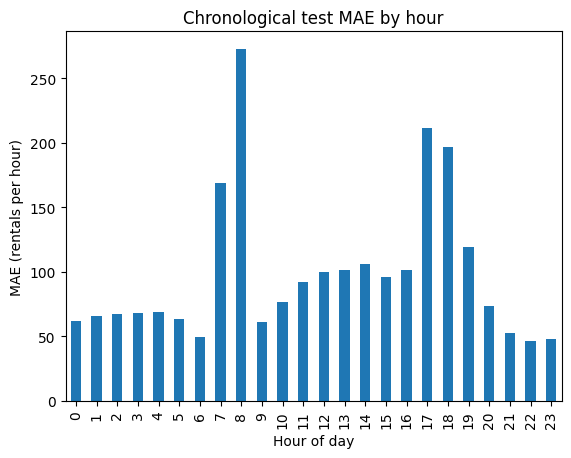

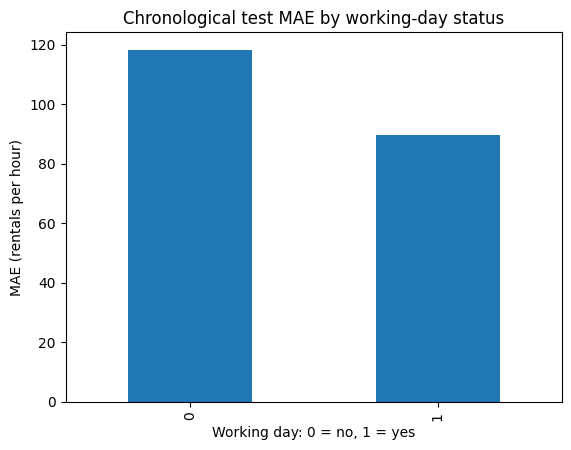

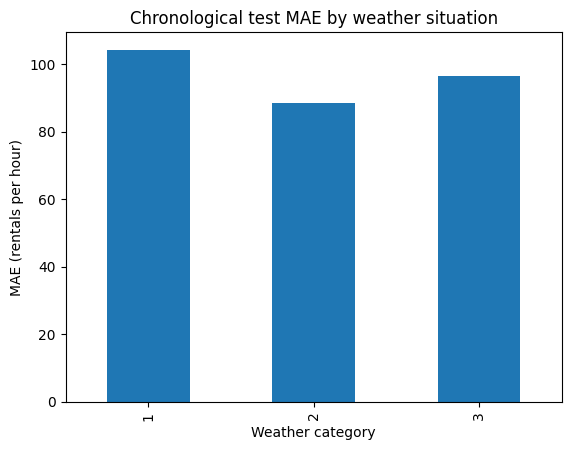

In [63]:
# Attach actual counts and predictions to the chronological test rows
error_analysis = X_test_b[['hr', 'workingday', 'weathersit']].copy()
error_analysis['actual'] = np.asarray(y_test_b).ravel()
error_analysis['predicted'] = np.asarray(y_pred_b).ravel()

# Calculate each test hour's absolute error
error_analysis['absolute_error'] = (error_analysis['actual'] - error_analysis['predicted']).abs()

# Within each group, count test rows, average absolute errors (MAE), and average actual rental counts (mean_demand)
hour_errors = error_analysis.groupby('hr').agg(
    sample_count=('absolute_error', 'size'),
    MAE=('absolute_error', 'mean'),
    mean_demand=('actual', 'mean'),
)

workingday_errors = error_analysis.groupby('workingday').agg(
    sample_count=('absolute_error', 'size'),
    MAE=('absolute_error', 'mean'),
    mean_demand=('actual', 'mean'),
)

weather_errors = error_analysis.groupby('weathersit').agg(
    sample_count=('absolute_error', 'size'),
    MAE=('absolute_error', 'mean'),
)

display(hour_errors.style.set_caption("Errors by hour of day"))
display(workingday_errors.style.set_caption("Errors by working-day status"))
display(weather_errors.style.set_caption("Errors by weather situation"))

# Plot MAE for each group

hour_errors['MAE'].plot.bar(
    title='Chronological test MAE by hour',
    xlabel='Hour of day',
    ylabel='MAE (rentals per hour)',
)
plt.show()

workingday_errors['MAE'].plot.bar(
    title='Chronological test MAE by working-day status',
    xlabel='Working day: 0 = no, 1 = yes',
    ylabel='MAE (rentals per hour)',
)
plt.show()

weather_errors['MAE'].plot.bar(
    title='Chronological test MAE by weather situation',
    xlabel='Weather category',
    ylabel='MAE (rentals per hour)',
)
plt.show()



Checkpoint:

- Which segment has the largest absolute errors?
> Hour `8` and `17` have the largest MAEs, at `272.88` and `212.86` rentals per hour.

- Is that also the segment with the highest demand?
> The highest-error hours also have relatively high average demand.

- Would normalized or percentage error tell a different story?
> Possibly. High-demand hours may have larger MAE but smaller errors relative to their average demand. I would need to calculate normalized errors to check whether the group ranking changes.

- What additional data could plausibly help, without claiming causation?
> Information available before prediction time, such as scheduled events, public-transit disruptions, or available bikes and docking capacity, might help explain demand patterns or recorded rental counts. Further evaluation would be needed to determine whether these features improve predictions.

## 9. Deliberately leaky variant

For demonstration only, construct a model that includes `casual` and
`registered`.

Keep the split and model family comparable to a valid experiment.

Before running it, predict what should happen. Then report its metrics and
explain why they are invalid for the stated task.

Do not call this the best model. Label it clearly as non-deployable.

In [64]:
# Recover the same chronological rows, adding the two leaky features
X_train_leaky = X_train_b.copy()
X_test_leaky = X_test_b.copy()

leaky_columns = ['casual', 'registered']

# Copy `casual` and `registered` from the original dataset into the leaky training table, using the same training rows
X_train_leaky[leaky_columns] = bike_sharing.loc[X_train_b.index, leaky_columns]
X_test_leaky[leaky_columns] = bike_sharing.loc[X_test_b.index, leaky_columns]

# Convert the numeric_features column names into list first, then concatenate the leaky columns to them
leaky_numeric_columns = numeric_features.columns.tolist() + leaky_columns

# Define scaling for all numerical columns, including the leaky counts, and one-hot encoding for categorical columns
leaky_preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), leaky_numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore"),
     categorical_features.columns.tolist()),
], remainder="drop")

# Separate pipeline with the same Ridge settings as Experiment B
leaky_model = Pipeline([
    ("preprocessor", leaky_preprocessor),
    ("regressor", clone(model_b.named_steps['regressor'])), # Clone the old Ridge model's configurations (w/o learned coefficients) at the regressor step
])

# Train the model and perform prediction
leaky_model.fit(X_train_leaky, y_train_b)
y_pred_leaky = leaky_model.predict(X_test_leaky)

# Compare both models on the **same test targets**
leakage_comparison = pd.DataFrame({
    "Model": [
        "Valid Ridge - Experiment B",
        "Deliberately leaky Ridge - non-deployable",
    ],
    "MAE": [
        mean_absolute_error(y_test_b, y_pred_b),
        mean_absolute_error(y_test_b, y_pred_leaky),
    ],
    "RMSE": [
        root_mean_squared_error(y_test_b, y_pred_b),
        root_mean_squared_error(y_test_b, y_pred_leaky),
    ],
    "R-squared": [
        r2_score(y_test_b, y_pred_b),
        r2_score(y_test_b, y_pred_leaky),
    ],
    "Valid at prediction time?": ["Yes", "No"],
})

display(leakage_comparison)

,Model,MAE,RMSE,R-squared,Valid at prediction time?
0,Valid Ridge - Experiment B,98.868171,133.906687,0.631152,Yes
1,Deliberately leaky Ridge - non-deployable,0.057786,0.074637,1.000000,No


Checkpoint:

- Why should this model approach a trivial arithmetic solution?
> The two features sum exactly to the target, so the model can learn an arithmetic identity instead of forecasting future demand. These counts reveal the answer in both the training and test inputs.

- If its score is not nearly perfect, what preprocessing or model limitation
  might explain the remaining error?
> Ridge regularization penalizes large coefficients, which can slightly pull the fitted model away from the exact arithmetic solution. Numerical precision may also contribute small errors.

- How is exact target leakage different from an unusually predictive but valid
  feature?
> Exact target leakage directly reveals the answer using information unavailable at the intended prediction time. A valid predictive feature is available beforehand and helps estimate the outcome without revealing it directly. For example, hour of day is known before the hour begins, while that hour’s completed rental counts are not.

## 10. Optional nonlinear comparison

This section is optional.
> * Test at most one nonlinear tabular regressor using the valid feature set.
> * Do not launch a search over many model families.
> * Use unchanged holdout definitions.
> * If you adjust model choices after seeing chronological-test results, explicitly state that the test set has begun acting like validation data.

,Split,Model,MAE,RMSE,R-squared
0,Random,Ridge,76.076467,102.334533,0.686166
1,Random,Random forest,31.505817,51.173985,0.921521
2,Chronological,Ridge,98.868171,133.906687,0.631152
3,Chronological,Random forest,54.824765,82.762339,0.859101


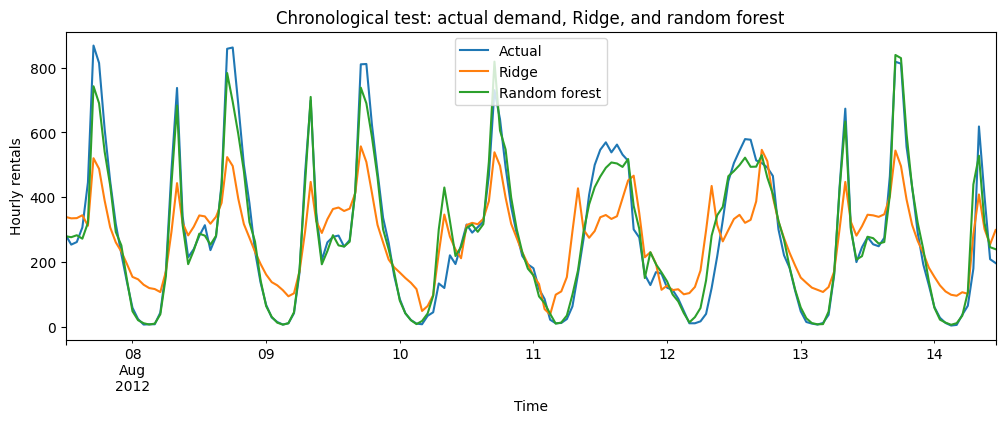

In [65]:
from sklearn.ensemble import RandomForestRegressor # Trains a model by growing predictions into trees, native support for NaNs
from sklearn.base import clone

# Settings for 100 estimators (where the model takes their average) with 1 worker (1 tree built at a time, more workers means job done sooner)
forest = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED,
    n_jobs=1
)

# Clone prior pipelines then replace the model under these pipelines (Ridge) with RandomForest
forest_model_a = clone(model_a).set_params(regressor=clone(forest))
forest_model_b = clone(model_b).set_params(regressor=clone(forest))

# Trains the pipeline forest_models with X_train and y_train (after conversion to numpy and ravel() to reduce to a 1D array)
forest_model_a.fit(X_train_a, y_train_a.to_numpy().ravel())
forest_model_b.fit(X_train_b, y_train_b.to_numpy().ravel())

# Perform prediction on the test splits after training completes
forest_pred_a = forest_model_a.predict(X_test_a)
forest_pred_b = forest_model_b.predict(X_test_b)

# Compare the four results:

comparison_rows = []

for split, model_name, actual, predicted in [
    ("Random", "Ridge", y_test_a, y_pred_a),
    ("Random", "Random forest", y_test_a, forest_pred_a),
    ("Chronological", "Ridge", y_test_b, y_pred_b),
    ("Chronological", "Random forest", y_test_b, forest_pred_b),
]:
  comparison_rows.append({
      "Split": split,
      "Model": model_name,
      "MAE": mean_absolute_error(actual, predicted),
      "RMSE": root_mean_squared_error(actual, predicted),
      "R-squared": r2_score(actual, predicted),
  })

nonlinear_results = pd.DataFrame(comparison_rows)
display(nonlinear_results)

# Compare peak predictions over the **same first seven days** used earlier:
forest_comparison = comparison[['Actual', 'Predicted']].copy()
forest_comparison = forest_comparison.rename(columns={"Predicted": "Ridge"})

# Create a new column that combines dteday and hr as dteday + hr
test_timestamps = (
    pd.to_datetime(X_test_b['dteday'])
    + pd.to_timedelta(X_test_b['hr'], unit='h')
)

# Add forest predictions as a column, matching rows by timestamp as index
forest_comparison['Random forest'] = pd.Series(
    forest_pred_b,
    index=pd.DatetimeIndex(test_timestamps),
)

# Select rows from the earliest test timestamp ('start') up to (not including) 7 days later
start = forest_comparison.index.min()
forest_week = forest_comparison.loc[forest_comparison.index < start + pd.Timedelta(days=7)]

forest_week.plot(
    figsize=(12, 4),
    xlabel='Time',
    ylabel='Hourly rentals',
    title='Chronological test: actual demand, Ridge, and random forest',
)
plt.show()

Checkpoint:

- What interaction or nonlinear pattern can this model capture that Ridge
  cannot?
> Ridge adds separate contributions from hour, working-day status, and other features. Without explicit interaction features, its working-day contribution is the same at every hour. A decision (random) tree can branch on combinations—for example, “Is it 8 AM? If yes, is it a working day?”—and learn different predictions for those combinations. A random forest averages predictions from many such trees.

- Did both random and chronological performance improve?
> Yes. Random-split MAE decreased from 76.08 to 31.51, and chronological MAE decreased from 98.87 to 54.82. RMSE decreased and R-squared increased in both experiments.

- Is the improvement large enough to justify added complexity?
> The improvement appears worthwhile for further investigation. Chronological MAE decreased by about 45%, and the plotted predictions track peaks and lows more closely. The tradeoffs are greater computational cost and less straightforward interpretation than Ridge.

## 11. Experiment log

Maintain this table:

| Run | Split | Features | Model | MAE | RMSE | R-squared | Valid at prediction time? |
|---|---|---|---|---:|---:|---:|---|
| 0A | Random | Valid | Dummy mean | | | | Yes |
| 0B | Chronological | Valid | Dummy mean | | | | Yes |
| 1A | Random | Valid | Ridge | | | | Yes |
| 1B | Chronological | Valid | Ridge | | | | Yes |
| 2 | Chosen split | Includes component counts | Deliberately leaky | | | | No |

Add no more than one optional-model row.

In [70]:
runs = [
    ("0A", "Random", "Valid", "Dummy mean", y_test_a, y_pred_dummy_a, "Yes"),
    ("0B", "Chronological", "Valid", "Dummy mean", y_test_b, y_pred_dummy_b, "Yes"),
    ("1A", "Random", "Valid", "Ridge", y_test_a, y_pred_a, "Yes"),
    ("1B", "Chronological", "Valid", "Ridge", y_test_b, y_pred_b, "Yes"),
    ("2", "Chronological", "Includes component counts", "Deliberately leaky Ridge", y_test_b, y_pred_leaky, "No"),
    ("3", "Chronological", "Valid", "Random forest", y_test_b, forest_pred_b, "Yes"),
]

experiment_rows = []

for run, split, features, model_name, actual, predicted, valid in runs:
  experiment_rows.append({
      "Run": run,
      "Split": split,
      "Features": features,
      "Model": model_name,
      "MAE": mean_absolute_error(actual, predicted),
      "RMSE": root_mean_squared_error(actual, predicted),
      "R-squared": r2_score(actual, predicted),
      "Valid at prediction time?": valid,
  })

  experiment_log = pd.DataFrame(experiment_rows)

display(
    experiment_log.style.set_caption("Experiment log").format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R-squared": "{:.4f}",
    })
)

,Run,Split,Features,Model,MAE,RMSE,R-squared,Valid at prediction time?
0,0A,Random,Valid,Dummy mean,143.12,182.67,-0.0000,Yes
1,0B,Chronological,Valid,Dummy mean,174.98,232.61,-0.1130,Yes
2,1A,Random,Valid,Ridge,76.08,102.33,0.6862,Yes
3,1B,Chronological,Valid,Ridge,98.87,133.91,0.6312,Yes
4,2,Chronological,Includes component counts,Deliberately leaky Ridge,0.06,0.07,1.0000,No
5,3,Chronological,Valid,Random forest,54.82,82.76,0.8591,Yes


## 12. Final report

Write a concise report containing:

1. **Problem**  
>    The goal was to predict total bike rentals during an hour, measured in rentals per hour, immediately before that hour begins. The predictions could help an operator plan bike availability and staffing.
2. **Data**  
>    The loaded dataset contained **17,379 hourly observations**, covering January 1, 2011 through December 31, 2012. Features included numerical weather measurements and categorical calendar information. Rental counts were right-skewed, with many low-demand hours and fewer high-demand hours. Some dates contained fewer than 24 recorded hours.
3. **Leakage controls**  
>   I excluded `casual` and `registered` because their sum equals the target, `cnt`, and their values are unavailable before the hour begins. I excluded `instant` because it is a row identifier. Raw dates were retained for chronological ordering but excluded from model inputs; existing calendar features represented date-related information.
4. **Evaluation design**  
>   I compared an 80/20 random split with a chronological split using the earliest 80% for training and latest 20% for testing. Both used 13,903 training rows and 3,476 test rows. Preprocessing was fitted separately on each training set. The chronological split better represents predicting future demand because its training observations precede its test observations.
5. **Results**  
>   Both Ridge and random forest improved over the training-mean baseline.
>   On the chronological test period, Ridge predictions were off by about **99 rentals per hour on average**, compared with **55** for random forest. Random-split results were more favorable for both models, suggesting that random evaluation gives an optimistic impression of future forecasting performance.
   | Split | Model | MAE | RMSE | R² |
   |---|---|---:|---:|---:|
   | Random | Dummy mean | 143\.12 | 182\.67 | −0.00003 |
   | Random | Ridge | 76\.08 | 102\.33 | 0\.686 |
   | Random | Random forest | 31\.51 | 51\.17 | 0\.922 |
   | Chronological | Dummy mean | 174\.98 | 232\.61 | −0.113 |
   | Chronological | Ridge | 98\.87 | 133\.91 | 0\.631 |
   | Chronological | Random forest | 54\.82 | 82\.76 | 0\.859 |

6. **Residual analysis**  
>   Using `residual = actual − predicted`, Ridge tended to underestimate large peaks and overestimate many overnight lows. Its chronological MAE was highest at **8 AM: 272.88 rentals**, followed by **5 PM: 211.87** and **6 PM: 196.79**. These groups contained 144–146 observations each. However, the highest average demand occurred at 5 PM, not 8 AM. Random forest followed peaks and lows more closely in the displayed week. These observations do not establish why the errors occurred.
7. **Leaky comparison**  
>   Adding `casual` and `registered` reduced chronological MAE to approximately **0\.058** and RMSE to **0\.075**, with R-squared approximately **1**. This model nearly reproduced the arithmetic identity defining the target. It is **non-deployable** for the stated task because the component counts are unknown before the hour begins.
8. **Limitations**  
>   Recorded weather was treated as if it were an available forecast; real forecast errors could reduce performance. A single chronological holdout does not establish reliability across different future periods. The dataset covers only two years from one bike-sharing system, limiting generalization. Ridge also produced some impossible negative rental predictions. Finally, the chronological test results informed the decision to investigate another model, so a fresh future evaluation would strengthen confidence in the final model choice.
9. **Recommendation**  
>   Random forest is worth further investigation: it reduced chronological MAE by about **45%** compared with Ridge. Before considering deployment, I would evaluate it across several chronological periods, use weather forecasts available at prediction time, and examine whether peak-demand improvements remain consistent. The current results support further testing rather than immediate deployment.
10. **What I now understand**
>    - Regression predicts numerical quantities, and MAE expresses average error in the target’s units.
>    - A chronological split evaluates future-period predictions differently from a random split.
>    - Features that reconstruct the target can produce excellent scores without solving the forecasting task.
>    - Mean residual can be near zero while individual errors remain large because positive and negative errors cancel.
>    - Random forests can learn feature interactions that require explicitly constructed interaction features in the Ridge pipeline.

In [66]:
# helpers

# .is_monotonic_increasing # Returns True if each value is greater than or equal to the previous value
# .ticklabel_format(style='plain', axis='y') # Turns off matplotlib scientific notation on y axis
# pd.api.types.is_datetime64_any_dtype(date_features) # Checks whether date_features follows any of the datetime64 formats
# np.asarray() converts an input (such as lists, tuples, or existing arrays) into a standard NumPy ndarray
# display() is used alongside dataframes in an interactive and user friendly manner
# pd.to_timedelta converts numbers as duration in hours
# pd.DatetimeIndex creates a pandas index containing date-and-time values

# Settings for 100 estimators (where the model takes their average) with 1 worker (1 tree built at a time, more workers means job done sooner)
# forest = RandomForestRegressor(
#     n_estimators=100,
#     random_state=RANDOM_SEED,
#     n_jobs=1
# )

# Minimum completion rubric

| Area | Completion standard |
|---|---|
| Framing | Target, units, prediction moment, and forecast-weather approximation are explicit. |
| Audit | Shapes, dtypes, categories, dates, missingness, duplicates, and target distribution are inspected. |
| Leakage | Arithmetic identity is verified and component counts are excluded from valid models. |
| Feature roles | Identifiers, continuous variables, coded categories, and dates are handled intentionally. |
| Evaluation | Both random and chronological holdouts are built and contrasted. |
| Baselines | Separate training-only dummy baselines are measured for both splits. |
| Pipeline | Learned preprocessing and Ridge are fit without test contamination. |
| Metrics | MAE, RMSE, R-squared, and residual behavior are correctly interpreted. |
| Error analysis | Chronological errors are analyzed by meaningful segments with sample counts. |
| Weak variant | Exact-leakage model is demonstrated and rejected. |
| Reproducibility | Seed, source, split boundaries, decisions, and run table are recorded. |
| Communication | Final report distinguishes interpolation-like evaluation from future forecasting. |

# Hint ladder

When blocked, state the section number and provide your attempted code, complete
error, observed shapes, and expected behavior. Assistance should progress from:

1. conceptual hint;
2. relevant pandas or scikit-learn mechanism;
3. pseudocode or unrelated miniature example;
4. partial project code;
5. complete local solution only if earlier levels fail.

# Optional extension (choose at most one)

- introduce a proper validation period between chronological train and test;
- encode hour and month with sine/cosine cyclical features;
- compare raw-target and `log1p`-target modeling with metrics returned to the
  original count scale;
- test one nonlinear model and analyze whether it improves peak-demand errors.

Do not perform all four. Stop after the core learning objectives are satisfied.